In [ ]:
# Chinese Weibo Sentiment Analysis
## Application to COVID-19 Vaccine Attitudes

Machine Learning Mini-Project

Team Members:
- Mayukh Pravin (PES2UG24CS271)
- Medha Singh (PES2UG24CS274)

Course: UE24CS352A - Machine Learning

In [ ]:
## 1. Problem Statement

The objective of this project is to develop machine-learning models
for binary sentiment classification of Chinese Weibo posts and
demonstrate their application to COVID-19/vaccine-related posts.

The project compares traditional machine-learning approaches with
a deep-learning approach and evaluates their performance using
accuracy, precision, recall and F1-score.

In [ ]:
## 2. Methodology

The project follows the following pipeline:

Raw Chinese Weibo Text
        ↓
Text Cleaning
        ↓
Chinese Word Segmentation using Jieba
        ↓
Feature Representation
        ↓
 ┌──────────────┬──────────────┐
 │              │              │
TF-IDF       TF-IDF         Token Sequences
 │              │              │
Naive Bayes    SVM           Bi-LSTM
 │              │              │
 └──────────────┴──────────────┘
                ↓
       Performance Evaluation
                ↓
       COVID/Vaccine Application

In [1]:
!pip install jieba scikit-learn pandas numpy matplotlib seaborn tensorflow openpyxl

In [2]:
import pandas as pd

df = pd.read_csv("weibo_senti_100k.csv")

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df.iloc[:, 0].value_counts())

Dataset shape: (119988, 2)

Column names:
['label', 'review']

First 5 rows:


,label,review
0,1,﻿更博了，爆照了，帅的呀，就是越来越爱你！生快傻缺[爱你][爱你][爱你]
1,1,@张晓鹏jonathan 土耳其的事要认真对待[哈哈]，否则直接开除。@丁丁看世界 很是细心...
2,1,姑娘都羡慕你呢…还有招财猫高兴……//@爱在蔓延-JC:[哈哈]小学徒一枚，等着明天见您呢/...
3,1,美~~~~~[爱你]
4,1,梦想有多大，舞台就有多大![鼓掌]



Data types:
label      int64
review    object
dtype: object

Missing values:
label     0
review    0
dtype: int64

Class distribution:
label
0    59995
1    59993
Name: count, dtype: int64


In [3]:
# Check how many posts are related to COVID-19 / vaccination

keywords = [
    "疫苗", "新冠", "冠状病毒", "COVID", "covid",
    "接种", "打针", "病毒", "疫情", "防疫",
    "辉瑞", "科兴", "国药", "疫苗接种"
]

pattern = "|".join(keywords)

vaccine_df = df[
    df["review"].astype(str).str.contains(pattern, case=False, na=False)
].copy()

print("Total posts:", len(df))
print("COVID/vaccine-related posts:", len(vaccine_df))

print("\nClass distribution:")
print(vaccine_df["label"].value_counts())

print("\nSample posts:")
display(vaccine_df[["label", "review"]].head(20))

Total posts: 119988
COVID/vaccine-related posts: 85

Class distribution:
label
0    67
1    18
Name: count, dtype: int64

Sample posts:


,label,review
710,1,S7B9[嘻嘻]//@一个闲人的小屋: H11N13//@橘子洲头2011: [笑哈哈]//...
1069,1,能病毒式传播的内容设计[思考] 这幅图表达的还挺完整的[哈哈]
11911,1,今天带米娃打针，在委屈地哭了一小鼻子后便开开心心地跟着麻麻去市场买菜了。回来也许有点小不适早...
17151,1,[哈哈]//@出版病毒杜辉:。。。不作死不会死//@李鲆:最右。。//@刘栋安魂曲://@斯...
17158,1,#⑤月刊?健康之道#【神奇的大蒜】想象，那浓郁芬芳的蒜香，[哈哈]大蒜能刺激人体免疫细胞的功...
17556,1,好！//@全熊张老能:嗯~找来看~最近看了＜白纸黑字＞＜最郁闷的中国人＞＜花冠病毒＞＜老狗＞...
18082,1,[哈哈] 梦想病毒营销的各位，真是不搞笑不成魔啊！//@丹崔: 乐死我了 //@Lisa37...
18321,1,#危机拯救者联盟# 正确回答：②由于菌株会变化，最好每年都接种疫苗。 [围观][爱你][...
20327,1,[给力]不上医院，不打针，不吃药，省心，省事，省费用！//@武夷山红骏茶业:[爱你]坚持喝，...
21913,1,菊花你个头啊[哈哈]//@国家动物博物馆员工:央视新闻也是瞎报道，什么十年潜心研究，2005...


In [4]:
# Create a clean copy of the full sentiment dataset

data = df[["label", "review"]].copy()

# Remove any accidental empty reviews
data = data.dropna(subset=["review"])

# Make sure labels are integers
data["label"] = data["label"].astype(int)

print("Total samples:", len(data))
print("\nClass distribution:")
print(data["label"].value_counts())

print("\nClass percentages:")
print(data["label"].value_counts(normalize=True) * 100)

Total samples: 119988

Class distribution:
label
0    59995
1    59993
Name: count, dtype: int64

Class percentages:
label
0    50.000833
1    49.999167
Name: proportion, dtype: float64


In [5]:
from sklearn.model_selection import train_test_split

# Take a balanced 30,000-sample subset
data_small, _ = train_test_split(
    data,
    train_size=30000,
    stratify=data["label"],
    random_state=42
)

print("Working dataset:", data_small.shape)
print(data_small["label"].value_counts())

Working dataset: (30000, 2)
label
1    15000
0    15000
Name: count, dtype: int64


In [6]:
!pip install jieba

In [7]:
import jieba
import re

def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove @mentions
    text = re.sub(r"@\S+", "", text)

    # Remove unnecessary special characters
    text = re.sub(r"[^\u4e00-\u9fffA-Za-z0-9]", " ", text)

    # Chinese word segmentation
    words = jieba.lcut(text)

    # Remove very short tokens
    words = [word for word in words if len(word.strip()) > 1]

    return " ".join(words)

data_small["clean_text"] = data_small["review"].apply(clean_text)

display(data_small[["review", "clean_text"]].head(10))

/usr/local/lib/python3.13/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.13/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.13/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
/usr/local/lib/python3.13/dist-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG

,review,clean_text
21413,谢谢亲！我们家海鲜火锅的特别，有你懂真好[可爱] 欢迎带朋友常来哦！ //@繁星满天飞扬,谢谢 我们 海鲜 火锅 特别 可爱 欢迎 朋友 常来
37598,[哈哈] //@泰哥秀:敬请期待啦，看老编如何舌战泰哥！[哈哈],哈哈
60318,面粉进去，面条出来！//@三能器具:会擀面条略过[哈哈]，话说我仅仅会这个了吧[挖鼻屎] /...,面粉 进去 面条 出来
42989,哈哈，这个方法好[赞] //@oliasg:那就抽，并且说：妈的你昨晚不回家去哪里了？然后说...,哈哈 这个 方法
44794,毛衣+衬衫+小黑裙！简单的单品，不一样的feel~[爱你]【私享穿衣顾问微信：Fashion...,毛衣 衬衫 小黑裙 简单 单品 一样 feel 私享 穿衣 顾问 微信 FashionTal...
44188,龙椅座得爽吧[嘻嘻],龙椅 嘻嘻
30189,我在这里: #首都大酒店锦云厅# 座无虚席。一切准备就绪。静待@于丹 老师的到来。[哈哈][...,这里 首都 大酒店 锦云厅 座无虚席 一切 准备就绪 静待 老师 到来 哈哈 围观
88039,这是哪家酒店啊？求曝光[怒] //@京东刘强东:晕！你让我明天到了宾馆如何入睡？,这是 哪家 酒店 曝光
74926,洗衣机版的“不作死就不会死”[衰],洗衣机 不作 不会
116517,"回覆@MookBeauty:今曰?房休息一天, 唔?野了, 放心, 唔?post 蛋糕相[嘻...",回覆 野了 放心 post 蛋糕 嘻嘻 想起 蛋糕 馋嘴 百感交集 委屈 抓狂 花心


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Separate features and labels
X = data_small["clean_text"]
y = data_small["label"]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# TF-IDF feature extraction
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

Training samples: 24000
Testing samples: 6000

TF-IDF training shape: (24000, 20000)
TF-IDF testing shape: (6000, 20000)


In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predictions
nb_pred = nb_model.predict(X_test_tfidf)

# Evaluation
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print("NAIVE BAYES RESULTS")
print("-------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))

NAIVE BAYES RESULTS
-------------------
Accuracy : 0.7978
Precision: 0.7929
Recall   : 0.8063
F1 Score : 0.7995


In [10]:
from sklearn.svm import LinearSVC

# Train SVM
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Predictions
svm_pred = svm_model.predict(X_test_tfidf)

# Evaluation
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("SVM RESULTS")
print("-----------")
print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1 Score :", round(svm_f1, 4))

SVM RESULTS
-----------
Accuracy : 0.8108
Precision: 0.8087
Recall   : 0.8143
F1 Score : 0.8115


In [11]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [12]:
# Use the same 30,000-sample dataset
lstm_text = data_small["clean_text"].values
lstm_labels = data_small["label"].values

# Train/test split
X_lstm_train, X_lstm_test, y_lstm_train, y_lstm_test = train_test_split(
    lstm_text,
    lstm_labels,
    test_size=0.20,
    random_state=42,
    stratify=lstm_labels
)

print("LSTM training samples:", len(X_lstm_train))
print("LSTM testing samples:", len(X_lstm_test))

LSTM training samples: 24000
LSTM testing samples: 6000


In [13]:
# Create tokenizer
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_lstm_train)

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_lstm_train)
X_test_seq = tokenizer.texts_to_sequences(X_lstm_test)

# Pad sequences to the same length
max_length = 80

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

vocab_size = min(20000, len(tokenizer.word_index) + 1)

print("Vocabulary size:", vocab_size)
print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Vocabulary size: 20000
Training shape: (24000, 80)
Testing shape: (6000, 80)


In [14]:
lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = lstm_model.fit(
    X_train_pad,
    y_lstm_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 36s 179ms/step - accuracy: 0.5015 - loss: 0.6937 - val_accuracy: 0.5075 - val_loss: 0.6931
Epoch 2/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 30s 177ms/step - accuracy: 0.4947 - loss: 0.6936 - val_accuracy: 0.5075 - val_loss: 0.6931
Epoch 3/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 30s 178ms/step - accuracy: 0.4981 - loss: 0.6934 - val_accuracy: 0.5075 - val_loss: 0.6931
Epoch 4/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 32s 189ms/step - accuracy: 0.4975 - loss: 0.6934 - val_accuracy: 0.5075 - val_loss: 0.6931
Epoch 5/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 30s 178ms/step - accuracy: 0.5006 - loss: 0.6933 - val_accuracy: 0.5075 - val_loss: 0.6931


In [16]:
# Predict probabilities
lstm_prob = lstm_model.predict(X_test_pad)

# Convert probabilities to 0/1
lstm_pred = (lstm_prob >= 0.5).astype(int).flatten()

# Evaluation
lstm_accuracy = accuracy_score(y_lstm_test, lstm_pred)
lstm_precision = precision_score(y_lstm_test, lstm_pred)
lstm_recall = recall_score(y_lstm_test, lstm_pred)
lstm_f1 = f1_score(y_lstm_test, lstm_pred)

print("LSTM RESULTS")
print("------------")
print("Accuracy :", round(lstm_accuracy, 4))
print("Precision:", round(lstm_precision, 4))
print("Recall   :", round(lstm_recall, 4))
print("F1 Score :", round(lstm_f1, 4))

188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step
LSTM RESULTS
------------
Accuracy : 0.5
Precision: 0.5
Recall   : 1.0
F1 Score : 0.6667


In [17]:
print("Actual label distribution:")
print(pd.Series(y_lstm_test).value_counts())

print("\nPredicted label distribution:")
print(pd.Series(lstm_pred).value_counts())

print("\nTraining accuracy:")
print(history.history["accuracy"])

print("\nValidation accuracy:")
print(history.history["val_accuracy"])

print("\nTraining loss:")
print(history.history["loss"])

print("\nValidation loss:")
print(history.history["val_loss"])

Actual label distribution:
0    3000
1    3000
Name: count, dtype: int64

Predicted label distribution:
1    6000
Name: count, dtype: int64

Training accuracy:
[0.5015277862548828, 0.4947222173213959, 0.4980555474758148, 0.4974536895751953, 0.5006018280982971]

Validation accuracy:
[0.5074999928474426, 0.5074999928474426, 0.5074999928474426, 0.5074999928474426, 0.5074999928474426]

Training loss:
[0.6937282681465149, 0.6935515403747559, 0.6934221982955933, 0.6934477090835571, 0.6933055520057678]

Validation loss:
[0.6930583715438843, 0.6930786967277527, 0.6930528879165649, 0.6931202411651611, 0.6930764317512512]


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D
)
from tensorflow.keras.optimizers import Adam

# Make sure labels are numeric
y_lstm_train = np.array(y_lstm_train).astype("float32")
y_lstm_test = np.array(y_lstm_test).astype("float32")

# Build improved LSTM model
lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    SpatialDropout1D(0.2),

    Bidirectional(
        LSTM(64, return_sequences=False)
    ),

    Dropout(0.4),

    Dense(32, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = lstm_model.fit(
    X_train_pad,
    y_lstm_train,
    validation_split=0.1,
    epochs=8,
    batch_size=128,
    verbose=1
)

Epoch 1/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 60s 313ms/step - accuracy: 0.7658 - loss: 0.4864 - val_accuracy: 0.8512 - val_loss: 0.3682
Epoch 2/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 54s 320ms/step - accuracy: 0.8753 - loss: 0.3159 - val_accuracy: 0.8487 - val_loss: 0.3768
Epoch 3/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 53s 311ms/step - accuracy: 0.9023 - loss: 0.2490 - val_accuracy: 0.8379 - val_loss: 0.4183
Epoch 4/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 82s 312ms/step - accuracy: 0.9183 - loss: 0.2039 - val_accuracy: 0.8267 - val_loss: 0.4802
Epoch 5/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 53s 311ms/step - accuracy: 0.9288 - loss: 0.1684 - val_accuracy: 0.8313 - val_loss: 0.5502
Epoch 6/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 81s 305ms/step - accuracy: 0.9369 - loss: 0.1478 - val_accuracy: 0.8225 - val_loss: 0.6517
Epoch 7/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 54s 317ms/step - accuracy: 0.9390 - loss: 0.1362 - val_accuracy: 0.8175 - val_loss: 0.7163
Epoch 8/8
169/169 ━━━━━━━━━━━━━━━━━━━━ 53s 313ms/step - accuracy: 0.9399 - loss: 0.1288 - 

In [20]:
lstm_prob = lstm_model.predict(X_test_pad)

lstm_pred = (lstm_prob >= 0.5).astype(int).flatten()

lstm_accuracy = accuracy_score(y_lstm_test, lstm_pred)
lstm_precision = precision_score(y_lstm_test, lstm_pred)
lstm_recall = recall_score(y_lstm_test, lstm_pred)
lstm_f1 = f1_score(y_lstm_test, lstm_pred)

print("IMPROVED LSTM RESULTS")
print("---------------------")
print("Accuracy :", round(lstm_accuracy, 4))
print("Precision:", round(lstm_precision, 4))
print("Recall   :", round(lstm_recall, 4))
print("F1 Score :", round(lstm_f1, 4))

print("\nPrediction distribution:")
print(pd.Series(lstm_pred).value_counts())

188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step
IMPROVED LSTM RESULTS
---------------------
Accuracy : 0.8148
Precision: 0.809
Recall   : 0.8243
F1 Score : 0.8166

Prediction distribution:
1    3057
0    2943
Name: count, dtype: int64


In [ ]:
## 3. Results

Three models were evaluated:

1. Naive Bayes — used as a baseline probabilistic classifier.
2. SVM — used as a traditional supervised machine-learning classifier.
3. Bi-LSTM — used to capture sequential information in the Chinese text.

The Bi-LSTM achieved the highest overall performance, while SVM
was the strongest traditional machine-learning model.

In [21]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "Bi-LSTM"],
    "Accuracy": [nb_accuracy, svm_accuracy, lstm_accuracy],
    "Precision": [nb_precision, svm_precision, lstm_precision],
    "Recall": [nb_recall, svm_recall, lstm_recall],
    "F1 Score": [nb_f1, svm_f1, lstm_f1]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.7978,0.7929,0.8063,0.7995
1,SVM,0.8108,0.8087,0.8143,0.8115
2,Bi-LSTM,0.8148,0.8090,0.8243,0.8166


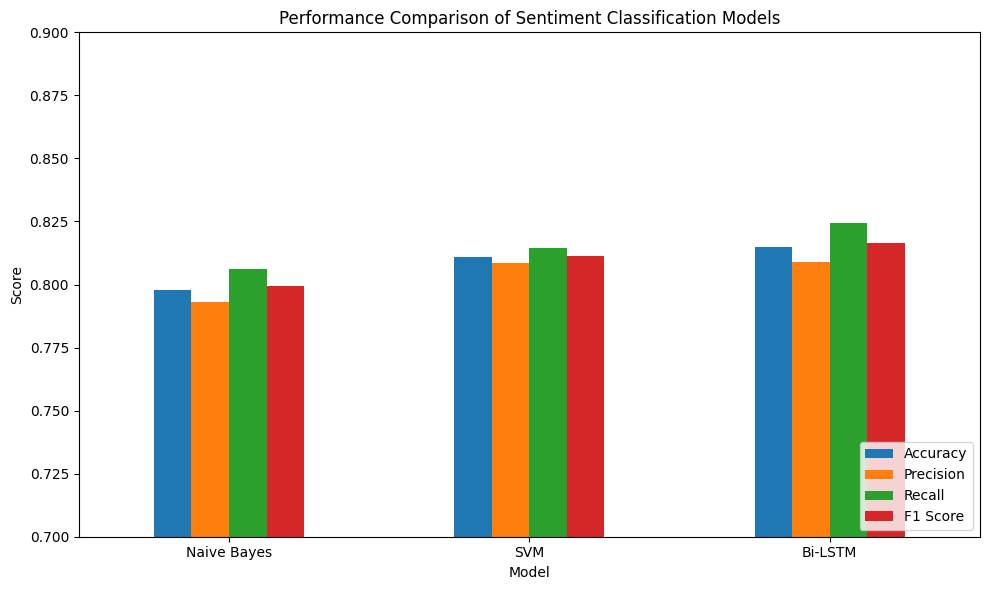

In [22]:
import matplotlib.pyplot as plt

results_plot = results.set_index("Model")

results_plot[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Sentiment Classification Models")
plt.ylabel("Score")
plt.ylim(0.7, 0.9)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

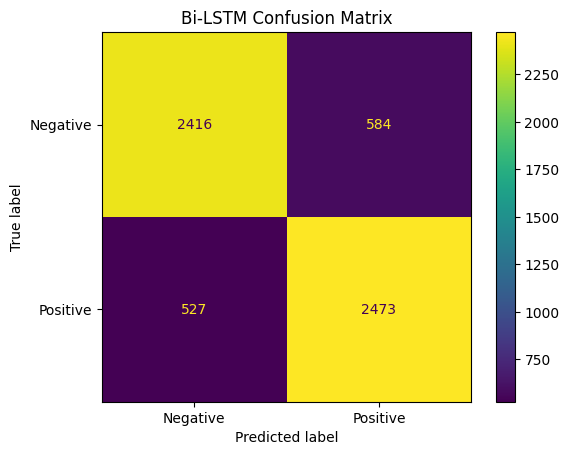

Confusion Matrix:
[[2416  584]
 [ 527 2473]]


In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_lstm_test, lstm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Bi-LSTM Confusion Matrix")
plt.show()

print("Confusion Matrix:")
print(cm)

In [24]:
from sklearn.metrics import classification_report

print(classification_report(
    y_lstm_test,
    lstm_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.82      0.81      0.81      3000
    Positive       0.81      0.82      0.82      3000

    accuracy                           0.81      6000
   macro avg       0.81      0.81      0.81      6000
weighted avg       0.81      0.81      0.81      6000



In [25]:
# Clean the vaccine-related posts
vaccine_df["clean_text"] = vaccine_df["review"].apply(clean_text)

# Convert text to sequences using our trained tokenizer
vaccine_sequences = tokenizer.texts_to_sequences(
    vaccine_df["clean_text"]
)

vaccine_padded = pad_sequences(
    vaccine_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Predict using our best Bi-LSTM model
vaccine_prob = lstm_model.predict(vaccine_padded, verbose=0)

vaccine_df["predicted_sentiment"] = (
    vaccine_prob >= 0.5
).astype(int).flatten()

# Convert labels to readable names
vaccine_df["sentiment"] = vaccine_df["predicted_sentiment"].map({
    0: "Negative",
    1: "Positive"
})

print("COVID/Vaccine-related posts analyzed:", len(vaccine_df))

print("\nPredicted sentiment:")
print(vaccine_df["sentiment"].value_counts())

display(
    vaccine_df[["review", "sentiment"]].head(15)
)

COVID/Vaccine-related posts analyzed: 85

Predicted sentiment:
sentiment
Negative    70
Positive    15
Name: count, dtype: int64


,review,sentiment
710,S7B9[嘻嘻]//@一个闲人的小屋: H11N13//@橘子洲头2011: [笑哈哈]//...,Positive
1069,能病毒式传播的内容设计[思考] 这幅图表达的还挺完整的[哈哈],Positive
11911,今天带米娃打针，在委屈地哭了一小鼻子后便开开心心地跟着麻麻去市场买菜了。回来也许有点小不适早...,Negative
17151,[哈哈]//@出版病毒杜辉:。。。不作死不会死//@李鲆:最右。。//@刘栋安魂曲://@斯...,Positive
17158,#⑤月刊?健康之道#【神奇的大蒜】想象，那浓郁芬芳的蒜香，[哈哈]大蒜能刺激人体免疫细胞的功...,Positive
17556,好！//@全熊张老能:嗯~找来看~最近看了＜白纸黑字＞＜最郁闷的中国人＞＜花冠病毒＞＜老狗＞...,Negative
18082,[哈哈] 梦想病毒营销的各位，真是不搞笑不成魔啊！//@丹崔: 乐死我了 //@Lisa37...,Positive
18321,#危机拯救者联盟# 正确回答：②由于菌株会变化，最好每年都接种疫苗。 [围观][爱你][...,Negative
20327,[给力]不上医院，不打针，不吃药，省心，省事，省费用！//@武夷山红骏茶业:[爱你]坚持喝，...,Negative
21913,菊花你个头啊[哈哈]//@国家动物博物馆员工:央视新闻也是瞎报道，什么十年潜心研究，2005...,Negative


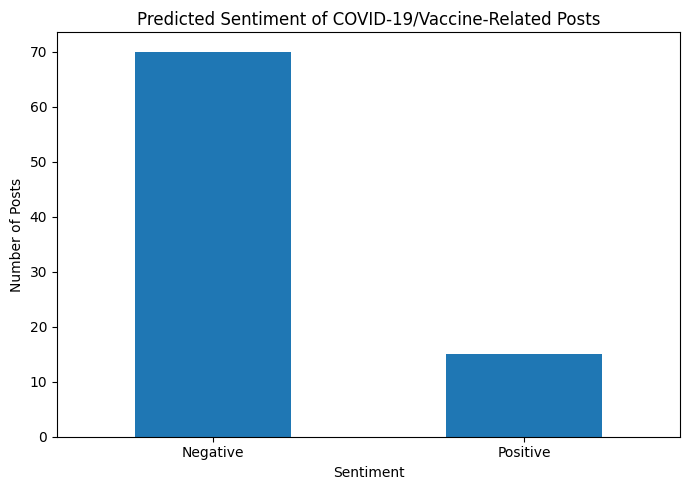

In [26]:
vaccine_counts = vaccine_df["sentiment"].value_counts()

plt.figure(figsize=(7, 5))

vaccine_counts.plot(kind="bar")

plt.title("Predicted Sentiment of COVID-19/Vaccine-Related Posts")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
def predict_sentiment(text):
    # Clean text
    cleaned = clean_text(text)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([cleaned])

    # Pad sequence
    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    # Prediction
    probability = float(lstm_model.predict(padded, verbose=0)[0][0])

    if probability >= 0.5:
        sentiment = "POSITIVE"
    else:
        sentiment = "NEGATIVE"

    return sentiment, probability


# Test example
text = "这个疫苗非常安全，我支持接种"
sentiment, probability = predict_sentiment(text)

print("Input:", text)
print("Prediction:", sentiment)
print("Confidence:", round(probability * 100, 2), "%")

Input: 这个疫苗非常安全，我支持接种
Prediction: NEGATIVE
Confidence: 0.02 %
